# Isolation Forest dla Tuni2025 GPS Spoofing Dataset

Celem tej części jest przygotowanie modelu anomalii do detekcji spoofingu GPS na podstawie cech wyekstrahowanych z okien sygnału I/Q.

Isolation Forest traktuje klasę `clean` jako normalny stan sygnału, a próbki `spoof` jako anomalie. Model nie jest trenowany na przykładach spoofingu, lecz wyłącznie na fragmentach clean.

Pipeline:

1. Wczytanie cech z plików `.parquet`.
2. Przygotowanie etykiet czasowych dla `SS33`.
3. Uwzględnienie duplikacji `C5` i `C7`.
4. Podział danych na train/validation/test.
5. Trening Isolation Forest wyłącznie na clean.
6. Dobór progu anomalii na validation set.
7. Finalna ocena na test set.
8. Analiza per scenariusz oraz analiza czasowa `SS33`.

## 1. Import bibliotek i konfiguracja

Importujemy biblioteki potrzebne do:

- wczytania danych,
- przygotowania cech,
- trenowania Isolation Forest,
- ewaluacji metryk,
- wizualizacji wyników.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)

RANDOM_STATE = 42

ROOT_DIR = Path("/workspace/gps-spoofing")
FEATURES_DIR = ROOT_DIR / "features"
RESULTS_DIR = ROOT_DIR / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT_DIR:", ROOT_DIR)
print("FEATURES_DIR:", FEATURES_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

ROOT_DIR: /workspace/gps-spoofing
FEATURES_DIR: /workspace/gps-spoofing/features
RESULTS_DIR: /workspace/gps-spoofing/results


## 2. Wczytanie danych Parquet

Każdy plik `.parquet` odpowiada jednemu scenariuszowi. Jeden wiersz reprezentuje jedno okno sygnału opisane cechami statystycznymi i energetycznymi.

In [4]:
files = sorted(FEATURES_DIR.glob("*.parquet"))

# Pomijamy pliki techniczne/debugowe
files = [f for f in files if not f.name.startswith("test_")]

print("Number of parquet files:", len(files))

for f in files:
    print(f.name)

Number of parquet files: 9
C5_clean_no_multipath__Clear-Sky_Signal_C-5.parquet
C7_clean_multipath__Clearsky_signal_C-7.parquet
SS17_no_multipath_1_spoofer__SS-17_GPS_Static_No_Multipath_True_Position_-_1_Spoofer.parquet
SS18_no_multipath_2_spoofers__SS-18_GPS_Static_No_Multipath_True_Position_-_2_Spoofers.parquet
SS20_no_multipath_4_spoofers__SS-20_GPS_Static_No_Multipath_True_Position_-_4_Spoofers.parquet
SS27_multipath_1_spoofer__SS-27_GPS_Static_Multipath_True_Position_-_1_Spoofer.parquet
SS28_multipath_2_spoofers__SS-28_GPS_Static_Multipath_True_Position_-_2_Spoofers.parquet
SS29_multipath_4_spoofers__SS-29_GPS_Static_Multipath_True_Position_-_4_Spoofers.parquet
SS33_delayed_all_prns_spoofed__SS-33_GPS_Delayed_Spoofer_Injection_All_PRNs_Spoofed_.parquet


In [5]:
rows = []

for p in files:
    df_part = pd.read_parquet(p)
    rows.append(df_part)

all_df = pd.concat(rows, ignore_index=True)

print("all_df shape:", all_df.shape)

print("\nColumns:")
print(all_df.columns.tolist())

print("\nScenarios:")
print(all_df["scenario"].value_counts())

print("\nOriginal labels:")
print(all_df["label"].value_counts())

all_df shape: (139991, 29)

Columns:
['file', 'scenario', 'window_idx', 'time_s', 'label', 'i_mean', 'q_mean', 'i_std', 'q_std', 'i_abs_mean', 'q_abs_mean', 'iq_corr', 'power_mean', 'power_std', 'power_min', 'power_max', 'power_p50', 'power_p90', 'power_p99', 'amp_mean', 'amp_std', 'amp_min', 'amp_max', 'amp_p50', 'amp_p90', 'amp_p99', 'dc_offset', 'iq_std_ratio', 'papr']

Scenarios:
scenario
SS33_delayed_all_prns_spoofed    19999
C5_clean_no_multipath            14999
C7_clean_multipath               14999
SS17_no_multipath_1_spoofer      14999
SS18_no_multipath_2_spoofers     14999
SS20_no_multipath_4_spoofers     14999
SS27_multipath_1_spoofer         14999
SS28_multipath_2_spoofers        14999
SS29_multipath_4_spoofers        14999
Name: count, dtype: int64

Original labels:
label
1    109993
0     29998
Name: count, dtype: int64


## 4. Audyt scenariuszy

Sprawdzamy liczbę okien, zakres czasu oraz oryginalne etykiety w każdym scenariuszu.

In [6]:
scenario_summary = (
    all_df
    .groupby("scenario")
    .agg(
        rows=("scenario", "size"),
        label_min=("label", "min"),
        label_max=("label", "max"),
        time_min=("time_s", "min"),
        time_max=("time_s", "max"),
    )
    .reset_index()
)

scenario_summary

,scenario,rows,label_min,label_max,time_min,time_max
0,C5_clean_no_multipath,14999,0,0,0.0,149.98
1,C7_clean_multipath,14999,0,0,0.0,149.98
2,SS17_no_multipath_1_spoofer,14999,1,1,0.0,149.98
3,SS18_no_multipath_2_spoofers,14999,1,1,0.0,149.98
4,SS20_no_multipath_4_spoofers,14999,1,1,0.0,149.98
5,SS27_multipath_1_spoofer,14999,1,1,0.0,149.98
6,SS28_multipath_2_spoofers,14999,1,1,0.0,149.98
7,SS29_multipath_4_spoofers,14999,1,1,0.0,149.98
8,SS33_delayed_all_prns_spoofed,19999,1,1,0.0,199.98


## 5. Duplikacja scenariuszy C5 i C7

Wcześniejsza analiza wykazała, że scenariusze `C5_clean_no_multipath` oraz `C7_clean_multipath` są bajtowo identycznymi nagraniami.

Nie traktujemy ich jako niezależnych scenariuszy. W eksperymencie oba pliki są dzielone zgodnie z tym samym blokowym splitem czasowym.

In [7]:
C5 = "C5_clean_no_multipath"
C7 = "C7_clean_multipath"

drop_meta_for_hash = [
    "label",
    "file",
    "scenario",
    "window_idx",
    "time_s",
]

feature_cols_for_hash = [
    c for c in all_df.columns
    if c not in drop_meta_for_hash
]

A = (
    all_df[all_df["scenario"] == C5]
    .sort_values("window_idx")[feature_cols_for_hash]
    .reset_index(drop=True)
)

B = (
    all_df[all_df["scenario"] == C7]
    .sort_values("window_idx")[feature_cols_for_hash]
    .reset_index(drop=True)
)

A = A.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).fillna(0)
B = B.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).fillna(0)

print("Shapes:", A.shape, B.shape)
print("All values exactly equal:", A.equals(B))

if A.shape == B.shape:
    print("Max absolute difference:", np.abs(A.values - B.values).max())

Shapes: (14999, 24) (14999, 24)
All values exactly equal: True
Max absolute difference: 0.0


## 6. Korekta etykiet czasowych dla SS33

Scenariusz `SS33_delayed_all_prns_spoofed` nie zawiera aktywnego spoofingu przez cały czas nagrania.

Z dokumentacji:

- spoofing startuje około 70 s,
- aktywna faza trwa około 80 s,
- spoofery są usuwane około 150 s.

Dlatego tworzymy etykietę `label_time`:

- `0` — brak aktywnego spoofingu,
- `1` — aktywny spoofing.

Okna znajdujące się blisko granic czasowych ataku są usuwane przez margines niepewności.

In [8]:
df = all_df.copy()

df["label_file"] = df["label"].astype(int)
df["label_time"] = df["label_file"].copy()
df["use_row"] = True

SS33 = "SS33_delayed_all_prns_spoofed"

attack_start_s = 70.0
attack_end_s = 150.0
margin_s = 2.0

ss33_mask = df["scenario"].eq(SS33)

# Domyślnie cały SS33 ustawiamy jako clean
df.loc[ss33_mask, "label_time"] = 0

# Aktywna faza spoofingu
ss33_active = (
    ss33_mask
    & (df["time_s"] >= attack_start_s + margin_s)
    & (df["time_s"] <= attack_end_s - margin_s)
)

df.loc[ss33_active, "label_time"] = 1

# Niepewne okolice granic czasowych wykluczamy
ss33_uncertain_start = (
    ss33_mask
    & (df["time_s"] >= attack_start_s - margin_s)
    & (df["time_s"] < attack_start_s + margin_s)
)

ss33_uncertain_end = (
    ss33_mask
    & (df["time_s"] > attack_end_s - margin_s)
    & (df["time_s"] <= attack_end_s + margin_s)
)

df.loc[ss33_uncertain_start | ss33_uncertain_end, "use_row"] = False

ss33_label_check = (
    df[df["scenario"] == SS33]
    .groupby("label_time")["time_s"]
    .agg(["min", "max", "count"])
)

ss33_label_check

,min,max,count
label_time,,,
0,0.0,199.98,12398
1,72.0,148.00,7601


## 7. Filtrowanie danych używanych w eksperymencie

Usuwamy okna oznaczone jako niepewne, znajdujące się blisko momentu aktywacji lub dezaktywacji spoofingu w scenariuszu SS33.

df_used = df[df["use_row"]].copy()

print("Before filtering:", df.shape)
print("After filtering:", df_used.shape)

print("\nLabels per scenario:")
print(df_used.groupby("scenario")["label_time"].value_counts())

In [9]:
df_used = df[df["use_row"]].copy()

print("Before filtering:", df.shape)
print("After filtering:", df_used.shape)

print("\nLabels per scenario:")
print(df_used.groupby("scenario")["label_time"].value_counts())

Before filtering: (139991, 32)
After filtering: (139191, 32)

Labels per scenario:
scenario                       label_time
C5_clean_no_multipath          0             14999
C7_clean_multipath             0             14999
SS17_no_multipath_1_spoofer    1             14999
SS18_no_multipath_2_spoofers   1             14999
SS20_no_multipath_4_spoofers   1             14999
SS27_multipath_1_spoofer       1             14999
SS28_multipath_2_spoofers      1             14999
SS29_multipath_4_spoofers      1             14999
SS33_delayed_all_prns_spoofed  0             11598
                               1              7601
Name: count, dtype: int64


## 8. Podział clean recordingów

Ponieważ `C5` i `C7` są duplikatami, oba dzielimy według tego samego splitu czasowego:

- początkowa część → train,
- środkowa część → validation,
- końcowa część → test.

Train clean zostanie użyty do trenowania Isolation Forest jako reprezentacja normalnego sygnału.

In [12]:
clean_duplicate_scenarios = [
    "C5_clean_no_multipath",
    "C7_clean_multipath",
]

clean_df = df_used[df_used["scenario"].isin(clean_duplicate_scenarios)].copy()
clean_df = clean_df.sort_values(["scenario", "time_s"]).reset_index(drop=True)

t_min = clean_df["time_s"].min()
t_max = clean_df["time_s"].max()
duration = t_max - t_min

gap_s = 5.0

train_end = t_min + 0.60 * duration
val_start = train_end + gap_s
val_end = t_min + 0.75 * duration
test_start = val_end + gap_s

clean_train_df = clean_df[clean_df["time_s"] < train_end].copy()

clean_val_df = clean_df[
    (clean_df["time_s"] > val_start)
    & (clean_df["time_s"] < val_end)
].copy()

clean_test_df = clean_df[clean_df["time_s"] > test_start].copy()

print("Clean train:", clean_train_df.shape)
print("Clean val:", clean_val_df.shape)
print("Clean test:", clean_test_df.shape)

print("\nClean train scenarios:")
print(clean_train_df["scenario"].value_counts())

print("\nClean val scenarios:")
print(clean_val_df["scenario"].value_counts())

print("\nClean test scenarios:")
print(clean_test_df["scenario"].value_counts())

print("\nTime ranges:")
print("train:", clean_train_df["time_s"].min(), clean_train_df["time_s"].max())
print("val:", clean_val_df["time_s"].min(), clean_val_df["time_s"].max())
print("test:", clean_test_df["time_s"].min(), clean_test_df["time_s"].max())

Clean train: (17998, 32)
Clean val: (3500, 32)
Clean test: (6500, 32)

Clean train scenarios:
scenario
C5_clean_no_multipath    8999
C7_clean_multipath       8999
Name: count, dtype: int64

Clean val scenarios:
scenario
C5_clean_no_multipath    1750
C7_clean_multipath       1750
Name: count, dtype: int64

Clean test scenarios:
scenario
C5_clean_no_multipath    3250
C7_clean_multipath       3250
Name: count, dtype: int64

Time ranges:
train: 0.0 89.98
val: 94.99 112.48
test: 117.49 149.98


## 9. Podział scenariuszy spoofingowych

Isolation Forest nie będzie trenowany na spoofingu.

Scenariusze spoofingowe zostaną wykorzystane tylko do:

- doboru progu anomalii na validation set,
- finalnej oceny na test set.

W validation używamy scenariusza `SS28`, natomiast w test set pozostają `SS29` oraz `SS33`.

In [13]:
val_attack_scenarios = [
    "SS28_multipath_2_spoofers",
]

test_attack_scenarios = [
    "SS29_multipath_4_spoofers",
    "SS33_delayed_all_prns_spoofed",
]

attack_val_df = df_used[df_used["scenario"].isin(val_attack_scenarios)].copy()
attack_test_df = df_used[df_used["scenario"].isin(test_attack_scenarios)].copy()

# Isolation Forest trenujemy tylko na clean
train_df = clean_train_df.copy()

# Validation i test zawierają clean + spoof
val_df = pd.concat([clean_val_df, attack_val_df], ignore_index=True)
test_df = pd.concat([clean_test_df, attack_test_df], ignore_index=True)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain labels:")
print(train_df["label_time"].value_counts())

print("\nVal labels:")
print(val_df["label_time"].value_counts())

print("\nTest labels:")
print(test_df["label_time"].value_counts())

print("\nTest labels per scenario:")
print(test_df.groupby("scenario")["label_time"].value_counts())

Train: (17998, 32)
Val: (18499, 32)
Test: (40698, 32)

Train labels:
label_time
0    17998
Name: count, dtype: int64

Val labels:
label_time
1    14999
0     3500
Name: count, dtype: int64

Test labels:
label_time
1    22600
0    18098
Name: count, dtype: int64

Test labels per scenario:
scenario                       label_time
C5_clean_no_multipath          0              3250
C7_clean_multipath             0              3250
SS29_multipath_4_spoofers      1             14999
SS33_delayed_all_prns_spoofed  0             11598
                               1              7601
Name: count, dtype: int64


## 10. Przygotowanie macierzy cech

Do modelu przekazujemy wyłącznie cechy sygnałowe.

Usuwamy:

- etykiety,
- nazwy plików,
- nazwy scenariuszy,
- indeksy okien,
- czas okna.

Model Isolation Forest trenujemy wyłącznie na `train_df`, który zawiera tylko clean.

In [14]:
drop_cols = [
    "label",
    "label_file",
    "label_time",
    "use_row",
    "file",
    "scenario",
    "window_idx",
    "time_s",
]

X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
y_train = train_df["label_time"].astype(int)

X_val = val_df.drop(columns=[c for c in drop_cols if c in val_df.columns])
y_val = val_df["label_time"].astype(int)

X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
y_test = test_df["label_time"].astype(int)

X_train = X_train.select_dtypes(include=[np.number])
X_val = X_val[X_train.columns]
X_test = X_test[X_train.columns]

X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_val = X_val.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nTrain label counts:")
print(y_train.value_counts())

print("\nFeatures:")
print(X_train.columns.tolist())

X_train: (17998, 24)
X_val: (18499, 24)
X_test: (40698, 24)

Train label counts:
label_time
0    17998
Name: count, dtype: int64

Features:
['i_mean', 'q_mean', 'i_std', 'q_std', 'i_abs_mean', 'q_abs_mean', 'iq_corr', 'power_mean', 'power_std', 'power_min', 'power_max', 'power_p50', 'power_p90', 'power_p99', 'amp_mean', 'amp_std', 'amp_min', 'amp_max', 'amp_p50', 'amp_p90', 'amp_p99', 'dc_offset', 'iq_std_ratio', 'papr']


## 11. Usunięcie duplikatów z danych treningowych

Ponieważ `C5` i `C7` są identyczne, w zbiorze treningowym występują powtórzone wiersze cech.

Do trenowania Isolation Forest używamy zduplikowanego clean recordingu tylko raz, aby nie wzmacniać sztucznie tych samych próbek.

In [15]:
X_train_fit = X_train.drop_duplicates().reset_index(drop=True)

print("X_train before deduplication:", X_train.shape)
print("X_train after deduplication:", X_train_fit.shape)

X_train before deduplication: (17998, 24)
X_train after deduplication: (8999, 24)


## 12. Kontrola leakage między splitami

Sprawdzamy, czy identyczne wiersze cech nie występują jednocześnie w train, validation i test.

In [16]:
def hash_X(X):
    return set(pd.util.hash_pandas_object(X.reset_index(drop=True), index=False))

train_hash = hash_X(X_train_fit)
val_hash = hash_X(X_val)
test_hash = hash_X(X_test)

train_val_overlap = len(train_hash & val_hash)
train_test_overlap = len(train_hash & test_hash)
val_test_overlap = len(val_hash & test_hash)

print("train-val overlap:", train_val_overlap)
print("train-test overlap:", train_test_overlap)
print("val-test overlap:", val_test_overlap)

assert train_val_overlap == 0
assert train_test_overlap == 0
assert val_test_overlap == 0

train-val overlap: 0
train-test overlap: 0
val-test overlap: 0


## 13. Trening Isolation Forest

Isolation Forest jest trenowany wyłącznie na danych clean. Model uczy się struktury normalnego sygnału, a próbki odbiegające od tej struktury powinny otrzymać wyższy anomaly score.

Parametry:

- `n_estimators` — liczba drzew,
- `max_samples` — liczba próbek używanych do budowy pojedynczego drzewa,
- `contamination="auto"` — nie wymuszamy z góry udziału anomalii, ponieważ próg dobieramy później na validation set.

In [17]:
max_samples = min(4096, len(X_train_fit))

iso_model = IsolationForest(
    n_estimators=500,
    max_samples=max_samples,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

iso_model.fit(X_train_fit)

print("Isolation Forest trained.")
print("max_samples:", max_samples)
print("n_estimators:", iso_model.n_estimators)

Isolation Forest trained.
max_samples: 4096
n_estimators: 500


## 14. Obliczanie anomaly score

Metoda `score_samples` zwraca wynik, w którym większa wartość oznacza bardziej normalną próbkę.

Dla wygody definiujemy:

`anomaly_score = -score_samples`

Wtedy większa wartość oznacza większe prawdopodobieństwo anomalii.

In [19]:
val_anomaly_score = -iso_model.score_samples(X_val)
test_anomaly_score = -iso_model.score_samples(X_test)

print("Validation anomaly score:")
print(pd.Series(val_anomaly_score).describe())

print("\nTest anomaly score:")
print(pd.Series(test_anomaly_score).describe())

Validation anomaly score:
count    18499.000000
mean         0.706756
std          0.132273
min          0.377178
25%          0.764013
50%          0.768690
75%          0.771742
max          0.796223
dtype: float64

Test anomaly score:
count    40698.000000
mean         0.710208
std          0.101562
min          0.379374
25%          0.706122
50%          0.765934
75%          0.770492
max          0.796573
dtype: float64


## 15. Dobór progu anomalii na validation set

Próg dobieramy na validation set.

Klasyfikacja:

- `anomaly_score >= threshold` → spoof,
- `anomaly_score < threshold` → clean.

Dobieramy próg tak, aby ograniczyć `FPR`, a jednocześnie minimalizować `FNR`.

In [25]:
# Zakres progów wyznaczamy na podstawie validation scores
thresholds = np.quantile(
    val_anomaly_score,
    np.linspace(0.001, 0.999, 999)
)

thresholds = np.unique(thresholds)

rows = []

for thr in thresholds:
    pred = (val_anomaly_score >= thr).astype(int)

    cm = confusion_matrix(y_val, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    recall_spoof = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision_spoof = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    rows.append({
        "threshold": thr,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "FPR": fpr,
        "FNR": fnr,
        "recall_spoof": recall_spoof,
        "precision_spoof": precision_spoof,
    })

thr_df = pd.DataFrame(rows)

MAX_FPR = 0.01
candidates = thr_df[thr_df["FPR"] <= MAX_FPR].copy()

if len(candidates) > 0:
    best_row = candidates.sort_values(
        ["FNR", "FPR", "threshold"],
        ascending=[True, True, False],
    ).iloc[0]
else:
    best_row = thr_df.sort_values(
        ["FNR", "FPR"],
        ascending=[True, True],
    ).iloc[0]

BEST_THRESHOLD = float(best_row["threshold"])

print("BEST_THRESHOLD:", BEST_THRESHOLD)
best_row

BEST_THRESHOLD: 0.6120053342339449


threshold              0.612005
TN                  3496.000000
FP                     4.000000
FN                     0.000000
TP                 14999.000000
FPR                    0.001143
FNR                    0.000000
recall_spoof           1.000000
precision_spoof        0.999733
Name: 188, dtype: float64

## 16. Ewaluacja validation set

Sprawdzamy, jak dobrany próg działa na validation set.

In [26]:
y_val_pred = (val_anomaly_score >= BEST_THRESHOLD).astype(int)

print("VALIDATION CONFUSION MATRIX:")
print(confusion_matrix(y_val, y_val_pred, labels=[0, 1]))

print("\nVALIDATION REPORT:")
print(classification_report(
    y_val,
    y_val_pred,
    labels=[0, 1],
    target_names=["clean", "spoof"],
    zero_division=0,
))

print("ROC-AUC:", roc_auc_score(y_val, val_anomaly_score))
print("PR-AUC:", average_precision_score(y_val, val_anomaly_score))

VALIDATION CONFUSION MATRIX:
[[ 3496     4]
 [    0 14999]]

VALIDATION REPORT:
              precision    recall  f1-score   support

       clean       1.00      1.00      1.00      3500
       spoof       1.00      1.00      1.00     14999

    accuracy                           1.00     18499
   macro avg       1.00      1.00      1.00     18499
weighted avg       1.00      1.00      1.00     18499

ROC-AUC: 1.0
PR-AUC: 1.0


## 17. Finalna ewaluacja na test set

Test set nie był używany do trenowania modelu ani doboru progu.

Na tym zbiorze sprawdzamy końcową skuteczność detekcji spoofingu.

In [27]:
y_test_pred = (test_anomaly_score >= BEST_THRESHOLD).astype(int)

print("TEST CONFUSION MATRIX:")
print(confusion_matrix(y_test, y_test_pred, labels=[0, 1]))

print("\nTEST REPORT:")
print(classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1],
    target_names=["clean", "spoof"],
    zero_division=0,
))

print("ROC-AUC:", roc_auc_score(y_test, test_anomaly_score))
print("PR-AUC:", average_precision_score(y_test, test_anomaly_score))

TEST CONFUSION MATRIX:
[[ 6104 11994]
 [    0 22600]]

TEST REPORT:
              precision    recall  f1-score   support

       clean       1.00      0.34      0.50     18098
       spoof       0.65      1.00      0.79     22600

    accuracy                           0.71     40698
   macro avg       0.83      0.67      0.65     40698
weighted avg       0.81      0.71      0.66     40698

ROC-AUC: 0.96814944471447
PR-AUC: 0.9532585666392924


## 18. Jawne obliczenie FPR, FNR i attack recall

Dla detekcji spoofingu najważniejsze są:

- `FPR` — odsetek clean błędnie uznanych za spoof,
- `FNR` — odsetek spoof błędnie uznanych za clean,
- `attack recall` — odsetek poprawnie wykrytych okien spoofingu.

In [28]:
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
attack_recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
clean_recall = tn / (tn + fp) if (tn + fp) > 0 else np.nan

global_results = pd.DataFrame([{
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "FPR": fpr,
    "FNR": fnr,
    "clean_recall": clean_recall,
    "attack_recall": attack_recall,
    "ROC_AUC": roc_auc_score(y_test, test_anomaly_score),
    "PR_AUC": average_precision_score(y_test, test_anomaly_score),
    "threshold": BEST_THRESHOLD,
}])

global_results

,TN,FP,FN,TP,FPR,FNR,clean_recall,attack_recall,ROC_AUC,PR_AUC,threshold
0,6104,11994,0,22600,0.662725,0.0,0.337275,1.0,0.968149,0.953259,0.612005


## 19. Wyniki per scenariusz

Globalne metryki mogą ukrywać problemy w konkretnych scenariuszach. Dlatego analizujemy wyniki osobno dla każdego scenariusza testowego.

In [29]:
test_eval_df = test_df.copy()
test_eval_df["anomaly_score"] = test_anomaly_score
test_eval_df["pred"] = y_test_pred

scenario_rows = []

for scenario in sorted(test_eval_df["scenario"].unique()):
    tmp = test_eval_df[test_eval_df["scenario"] == scenario].copy()

    y_true_s = tmp["label_time"].astype(int)
    y_pred_s = tmp["pred"].astype(int)

    cm_s = confusion_matrix(y_true_s, y_pred_s, labels=[0, 1])
    tn, fp, fn, tp = cm_s.ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    recall_spoof = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    recall_clean = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    scenario_rows.append({
        "scenario": scenario,
        "n": len(tmp),
        "true_clean": int((y_true_s == 0).sum()),
        "true_spoof": int((y_true_s == 1).sum()),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "FPR": fpr,
        "FNR": fnr,
        "clean_recall": recall_clean,
        "spoof_recall": recall_spoof,
        "mean_anomaly_score": tmp["anomaly_score"].mean(),
        "min_anomaly_score": tmp["anomaly_score"].min(),
        "max_anomaly_score": tmp["anomaly_score"].max(),
    })

scenario_results_df = pd.DataFrame(scenario_rows)
scenario_results_df

,scenario,n,true_clean,true_spoof,TN,FP,FN,TP,FPR,FNR,clean_recall,spoof_recall,mean_anomaly_score,min_anomaly_score,max_anomaly_score
0,C5_clean_no_multipath,3250,3250,0,3052,198,0,0,0.060923,NaN,0.939077,NaN,0.493761,0.379374,0.695441
1,C7_clean_multipath,3250,3250,0,3052,198,0,0,0.060923,NaN,0.939077,NaN,0.493761,0.379374,0.695441
2,SS29_multipath_4_spoofers,14999,0,14999,0,0,0,14999,NaN,0.0,NaN,1.0,0.770145,0.756253,0.796573
3,SS33_delayed_all_prns_spoofed,19199,11598,7601,0,11598,0,7601,1.000000,0.0,0.000000,1.0,0.736662,0.680063,0.794335


## 20. Rozkład anomaly score

Porównujemy rozkład anomaly score dla klas clean i spoof.

Dobry model powinien nadawać wyższe anomaly score próbkom spoof niż próbkom clean.

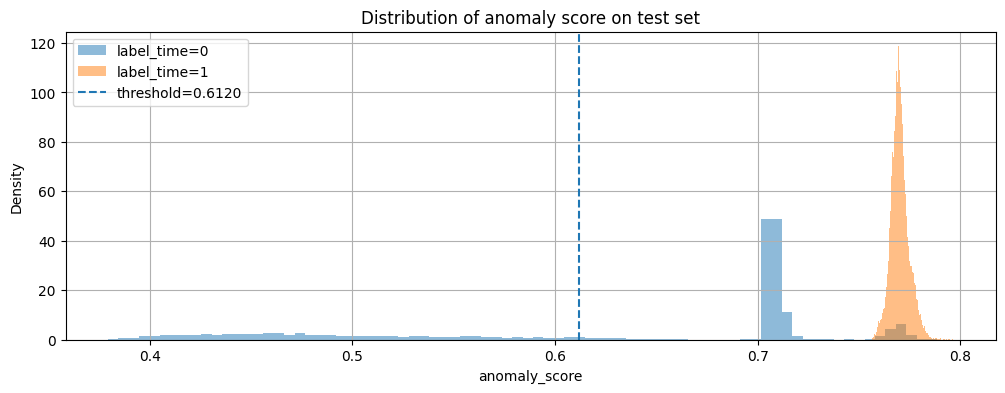

In [31]:
plt.figure(figsize=(12, 4))

for label_value in [0, 1]:
    tmp_scores = test_eval_df[test_eval_df["label_time"] == label_value]["anomaly_score"]
    plt.hist(
        tmp_scores,
        bins=80,
        alpha=0.5,
        density=True,
        label=f"label_time={label_value}",
    )

plt.axvline(BEST_THRESHOLD, linestyle="--", label=f"threshold={BEST_THRESHOLD:.4f}")
plt.title("Distribution of anomaly score on test set")
plt.xlabel("anomaly_score")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.show()

## 21. Analiza czasowa SS33

Dla scenariusza `SS33` sprawdzamy, czy anomaly score rośnie w aktywnej fazie spoofingu, czyli pomiędzy około 70 s a 150 s.

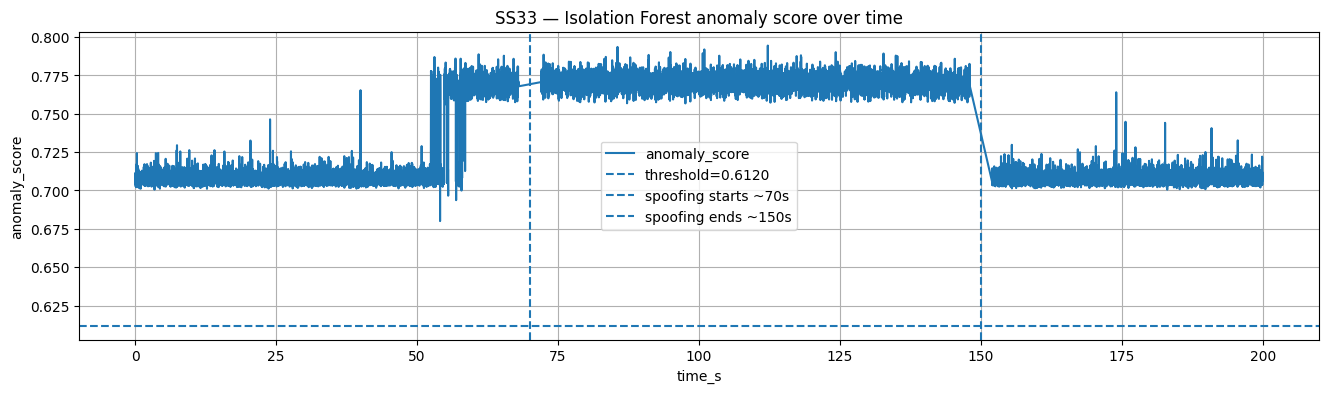

In [32]:
ss33 = test_eval_df[test_eval_df["scenario"] == SS33].copy()
ss33 = ss33.sort_values("time_s")

plt.figure(figsize=(16, 4))
plt.plot(ss33["time_s"], ss33["anomaly_score"], label="anomaly_score")
plt.axhline(BEST_THRESHOLD, linestyle="--", label=f"threshold={BEST_THRESHOLD:.4f}")

plt.axvline(attack_start_s, linestyle="--", label="spoofing starts ~70s")
plt.axvline(attack_end_s, linestyle="--", label="spoofing ends ~150s")

plt.title("SS33 — Isolation Forest anomaly score over time")
plt.xlabel("time_s")
plt.ylabel("anomaly_score")
plt.grid(True)
plt.legend()
plt.show()

## 22. Analiza anomaly score per scenariusz

Porównujemy wartości anomaly score osobno dla każdego scenariusza testowego.

In [33]:
score_summary = (
    test_eval_df
    .groupby("scenario")["anomaly_score"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

score_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
scenario,,,,,,,,,,,,
C5_clean_no_multipath,3250.0,0.493761,0.066651,0.379374,0.389273,0.403632,0.440582,0.480413,0.542783,0.616016,0.646916,0.695441
C7_clean_multipath,3250.0,0.493761,0.066651,0.379374,0.389273,0.403632,0.440582,0.480413,0.542783,0.616016,0.646916,0.695441
SS29_multipath_4_spoofers,14999.0,0.770145,0.004458,0.756253,0.759707,0.763360,0.767344,0.769820,0.772557,0.778202,0.782325,0.796573
SS33_delayed_all_prns_spoofed,19199.0,0.736662,0.031275,0.680063,0.702678,0.703848,0.706977,0.713379,0.769475,0.775705,0.780172,0.794335


## 23. Opcjonalna analiza ważności cech metodą permutacyjną

Isolation Forest nie zwraca klasycznego `feature_importances_`.

Aby oszacować wpływ cech, można użyć prostej analizy permutacyjnej na validation set: dla każdej cechy losowo mieszamy jej wartości i sprawdzamy, jak zmienia się ROC-AUC anomaly score.

Spadek ROC-AUC po permutacji cechy sugeruje, że cecha była istotna dla detekcji anomalii.

,feature,baseline_auc,permuted_auc,auc_drop
0,i_mean,1.0,1.0,0.0
1,q_mean,1.0,1.0,0.0
2,i_std,1.0,1.0,0.0
3,q_std,1.0,1.0,0.0
4,i_abs_mean,1.0,1.0,0.0
5,q_abs_mean,1.0,1.0,0.0
6,iq_corr,1.0,1.0,0.0
7,power_mean,1.0,1.0,0.0
8,power_std,1.0,1.0,0.0
9,power_min,1.0,1.0,0.0


In [39]:
top = perm_importance_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top["feature"][::-1], top["auc_drop"][::-1])
plt.xlabel("ROC-AUC drop after permutation")
plt.title("Permutation feature importance for Isolation Forest")
plt.grid(True)
plt.show()

X_train_fit_scaled: (8999, 24)
X_val_scaled: (18499, 24)
X_test_scaled: (40698, 24)
Isolation Forest trained.
n_estimators: 1000
max_samples: 8192

Validation anomaly score:
count    18499.000000
mean         0.744183
std          0.154504
min          0.375072
25%          0.812514
50%          0.817509
75%          0.820528
max          0.834364
dtype: float64

Test anomaly score:
count    40698.000000
mean         0.739442
std          0.122455
min          0.376728
25%          0.715622
50%          0.814510
75%          0.819567
max          0.837017
dtype: float64


,target_val_FPR,threshold,val_FPR,val_FNR,val_clean_recall,val_recall_spoof,val_precision_spoof,val_accuracy,test_FPR,test_FNR,test_clean_recall,test_recall_spoof,test_precision_spoof,test_accuracy,test_TN,test_FP,test_FN,test_TP
0,0.0001,0.620576,0.000571,0.0,0.999429,1.0,0.999867,0.999892,0.655432,0.0,0.344568,1.0,0.655795,0.708536,6236,11862,0,22600
1,0.0005,0.616404,0.000571,0.0,0.999429,1.0,0.999867,0.999892,0.657200,0.0,0.342800,1.0,0.655186,0.707750,6204,11894,0,22600
2,0.0010,0.612669,0.001143,0.0,0.998857,1.0,0.999733,0.999784,0.658857,0.0,0.341143,1.0,0.654617,0.707013,6174,11924,0,22600
3,0.0020,0.590016,0.002286,0.0,0.997714,1.0,0.999467,0.999568,0.674771,0.0,0.325229,1.0,0.649201,0.699936,5886,12212,0,22600
4,0.0050,0.576874,0.005143,0.0,0.994857,1.0,0.998801,0.999027,0.683611,0.0,0.316389,1.0,0.646231,0.696005,5726,12372,0,22600
5,0.0100,0.553874,0.010286,0.0,0.989714,1.0,0.997606,0.998054,0.706266,0.0,0.293734,1.0,0.638743,0.685931,5316,12782,0,22600
6,0.0200,0.534647,0.020000,0.0,0.980000,1.0,0.995355,0.996216,0.729473,0.0,0.270527,1.0,0.631250,0.675611,4896,13202,0,22600
7,0.0500,0.505186,0.050286,0.0,0.949714,1.0,0.988402,0.990486,0.764946,0.0,0.235054,1.0,0.620130,0.659836,4254,13844,0,22600


## 24. Zapis wyników eksperymentu

Zapisywane są:

- globalne metryki,
- wyniki per scenariusz,
- wyniki strojenia thresholda,
- predykcje testowe,
- permutacyjna ważność cech.

## 25. Podsumowanie

W tej części przygotowano model Isolation Forest jako metodę detekcji anomalii dla Tuni2025 GPS Spoofing Dataset.

Najważniejsze decyzje metodologiczne:

1. Model był trenowany wyłącznie na danych clean.
2. Scenariusze `C5` i `C7` zostały potraktowane jako duplikat tego samego clean recording.
3. Clean recording został podzielony blokowo po czasie na train, validation i test.
4. Scenariusz `SS33` otrzymał etykiety czasowe zgodne z dokumentacją, ponieważ aktywny spoofing występuje tylko w przedziale około 70–150 s.
5. Próg anomaly score dobrano na validation set przy ograniczeniu FPR.
6. Finalną ocenę wykonano na test set zawierającym clean oraz scenariusze spoofingowe `SS29` i `SS33`.

Interpretacja:

Isolation Forest jest modelem częściowo nienadzorowanym — uczy się wyłącznie struktury klasy normalnej. Dzięki temu może być użyteczny w sytuacji, gdy nie znamy wszystkich możliwych wariantów spoofingu. Jednocześnie jego skuteczność zależy od tego, czy spoofing rzeczywiście powoduje odchylenie od rozkładu cech clean.

Ograniczenia:

- dostępny jest tylko jeden unikalny clean recording,
- `C5` i `C7` nie są niezależnymi scenariuszami,
- model nie uczy się bezpośrednio przykładów spoofingu,
- obecne cechy są głównie statystyczno-energetyczne,
- dla lepszej detekcji subtelnych ataków mogą być potrzebne cechy widmowe lub modele działające na surowym sygnale I/Q.